In [14]:
# From past Labs

from skimage.color import rgb2hsv, rgb2gray
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects, binary_dilation
from skimage.transform import rotate, resize, AffineTransform, warp
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops
import matplotlib.image as mpimg


import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from src.Project_utils import *

from sklearn.metrics import accuracy_score, f1_score
import cv2

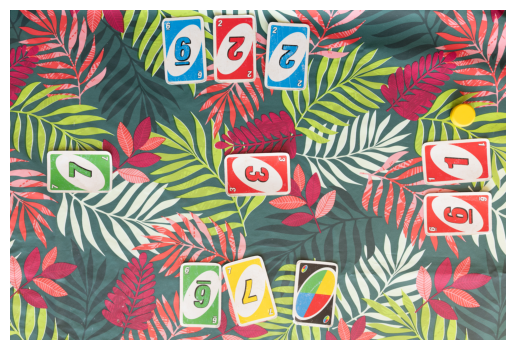

In [158]:
# Printer une image
img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000915.jpg") #image with leaves
#img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000775.jpg") #fond blanc


plt.imshow(img)
plt.axis("off")
plt.show()

In [159]:
def find_contour(images: np.ndarray):
    """
    Find the contours for the set of images
    
    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images to process

    Return
    ------
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the 
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements 
        that form the contour. 
    """

    # Get number of images to process
    N, _, _ = np.shape(images)
    # Fill in dummy values (fake points)
    contours = [np.array([[0, 0], [1, 1]]) for i in range(N)]

    # ------------------
    # Your code here ... 
    # ------------------
    for i in range(N):
        contours[i], _ = cv2.findContours(images[i].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contours[i] = contours[i][0][:, 0, :]

    return contours
    

In [160]:
def display_img_with_contour(
    image: np.ndarray,
    label: str,
    title: str,
    cnt: np.ndarray = None):

    # Create ONE large figure
    fig, axis = plt.subplots(figsize=(8, 8))

    # Show image
    axis.imshow(image, interpolation="nearest")

    # Remove axes
    axis.axis("off")

    # Small title above image
    axis.set_title(label, fontsize=16)

    # Draw contour
    if cnt is not None and len(cnt) > 0:
        axis.plot(cnt[:, 0], cnt[:, 1], 'r-', linewidth=2)

    # Main title
    fig.suptitle(title, fontsize=20)

    plt.tight_layout()
    plt.show()

(13320, 2)
(2662, 4000, 3)


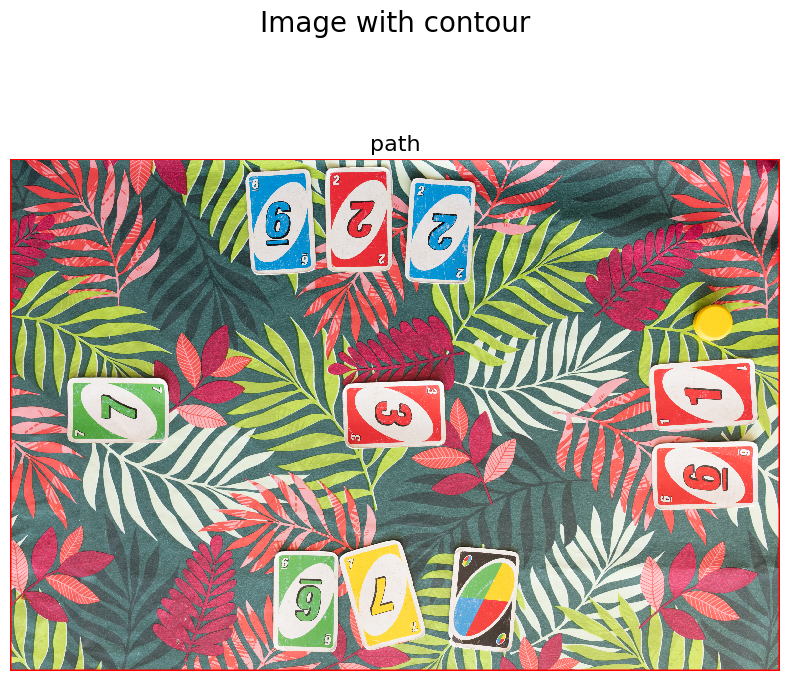

In [161]:
contours = find_contour(np.array([img[:, :, 0]]))
print(contours[0].shape)
print(img.shape)
display_img_with_contour(img, "path", "Image with contour", cnt=contours[0])

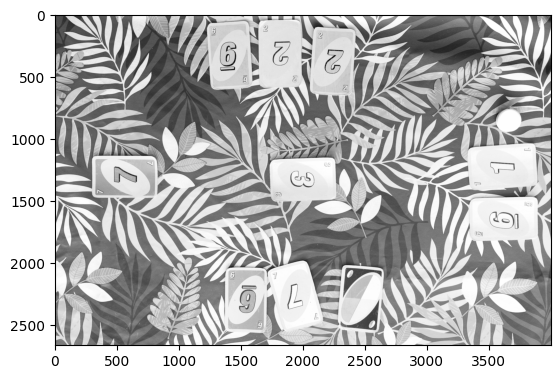

In [162]:
#get hsv value of the image
img_hsv = rgb2hsv(img)
plt.imshow(img_hsv[:,:,2], cmap='gray')

In [186]:
def extract_hsv_channels(img):
    """
    Extract HSV channels from the input image.

    """
    # Get the shape of the input image
    M, N, C = np.shape(img)

    # Define default values for HSV channels
    data_h = np.zeros((M, N))
    data_s = np.zeros((M, N))
    data_v = np.zeros((M, N))

    data_hsv = rgb2hsv(img)
    data_h = data_hsv[:, :, 0]
    data_s = data_hsv[:, :, 1]
    data_v = data_hsv[:, :, 2]

    return data_h, data_s, data_v


def apply_closing(img_th, disk_size):

    img_closing = np.zeros_like(img_th)
    img_closing = closing(img_th, disk(disk_size))

    return img_closing

def apply_opening(img_th, disk_size):

    img_opening = np.zeros_like(img_th)

    img_opening = opening(img_th, disk(disk_size))

    return img_opening

def apply_opening(img_th, disk_size):

    img_opening = np.zeros_like(img_th)

    img_opening = opening(img_th, disk(disk_size))

    return img_opening



def apply_hsv_threshold_v2(img, mode="red"):

    M, N, C = np.shape(img)

    data_h, data_s, data_v = extract_hsv_channels(img=img)

    if mode == "red":
        h_min1, h_max1 = 0.0, 0.05 # car 2 pics
        h_min2, h_max2 = 0.95, 1.0
        s_min, s_max = 0.4, 1.0
        v_min, v_max = 0.3, 1.0
        img_th = (
            (((data_h >= h_min1) & (data_h <= h_max1)) | 
             ((data_h >= h_min2) & (data_h <= h_max2))) &
            (data_s > s_min) & (data_s < s_max) &
            (data_v > v_min) & (data_v < v_max)
        )
        return img_th

    if mode == "blue":
        h_min, h_max = 0.52, 0.68
        s_min, s_max = 0.3, 1.0
        v_min, v_max = 0.3, 1.0

    if mode == "yellow":
        h_min, h_max = 0.06, 0.20
        s_min, s_max = 0.2, 1.0
        v_min, v_max = 0.8, 1.0

    if mode == "green":
        # Vert : Hue ~0.25-0.45
        h_min, h_max = 0.22, 0.48
        s_min, s_max = 0.3, 1.0
        v_min, v_max = 0.3, 1.0

    if mode == "black":
        h_min, h_max = 0.0, 1.0  
        s_min, s_max = 0.0, 1.0 
        v_min, v_max = 0.0, 0.50  

    img_th = (
        (data_h > h_min) & (data_h < h_max) &
        (data_s > s_min) & (data_s < s_max) &
        (data_v > v_min) & (data_v < v_max)
    )

    return img_th


def find_area_by_type(
    img: np.ndarray,
    mode: str = "red",
    visualize_hsv: bool = False,
    visualize_mask: bool = False,
    disk_size: int = 20,
    object_min_size: int = 30,
):

    if visualize_hsv:
        plot_colors_histo(
            img=img,
            func=extract_hsv_channels,
            labels=["Hue", "Saturation", "Value"],
        )

    img_th = apply_hsv_threshold_v2(img, mode=mode)

    if visualize_mask:
        plot_thresholded_image(
            img=img,
            func=lambda img: apply_hsv_threshold_v2(img, mode=mode),
            title=f"{mode.capitalize()} detection in HSV space"
        )

    out_mask = apply_opening(img_th, disk_size)
    out_mask = apply_closing(out_mask, disk_size)
    


    #out_mask = remove_small_objects(out_mask, min_size=object_min_size)


    return out_mask


In [164]:
'''
M, N, C= np.shape(img)
mask_red = np.zeros((M, N))
mask_blue = np.zeros((M, N))
mask_green = np.zeros((M, N))
mask_yellow = np.zeros((M, N))
mask_black = np.zeros((M, N))

# Sans plot qui prend du temps

mask_red = apply_hsv_threshold_v2(img, mode="red")
mask_blue = apply_hsv_threshold_v2(img, mode="blue")
mask_green = apply_hsv_threshold_v2(img, mode="green")
mask_yellow = apply_hsv_threshold_v2(img, mode="yellow")
mask_black = apply_hsv_threshold_v2(img, mode="black")
'''

'\nM, N, C= np.shape(img)\nmask_red = np.zeros((M, N))\nmask_blue = np.zeros((M, N))\nmask_green = np.zeros((M, N))\nmask_yellow = np.zeros((M, N))\nmask_black = np.zeros((M, N))\n\n# Sans plot qui prend du temps\n\nmask_red = apply_hsv_threshold_v2(img, mode="red")\nmask_blue = apply_hsv_threshold_v2(img, mode="blue")\nmask_green = apply_hsv_threshold_v2(img, mode="green")\nmask_yellow = apply_hsv_threshold_v2(img, mode="yellow")\nmask_black = apply_hsv_threshold_v2(img, mode="black")\n'

In [165]:
def combined_mask(img, color_masks):

    combined_mask = np.zeros_like(list(color_masks.values())[0])
    for mask in color_masks.values():
        combined_mask = combined_mask | mask
    return combined_mask

color_masks = {
    'red': apply_hsv_threshold_v2(img, mode='red'),
    'blue': apply_hsv_threshold_v2(img, mode='blue'),
    'yellow': apply_hsv_threshold_v2(img, mode='yellow'),
    'green': apply_hsv_threshold_v2(img, mode='green'),
    'black': apply_hsv_threshold_v2(img, mode='black'),
}




(2662, 4000)


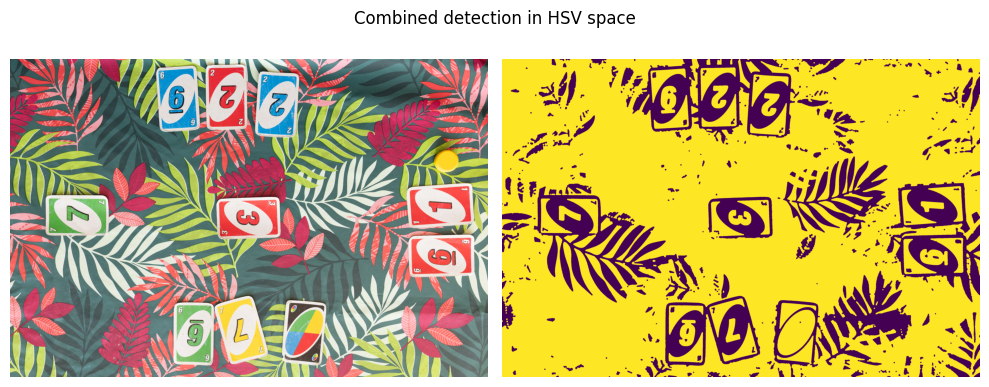

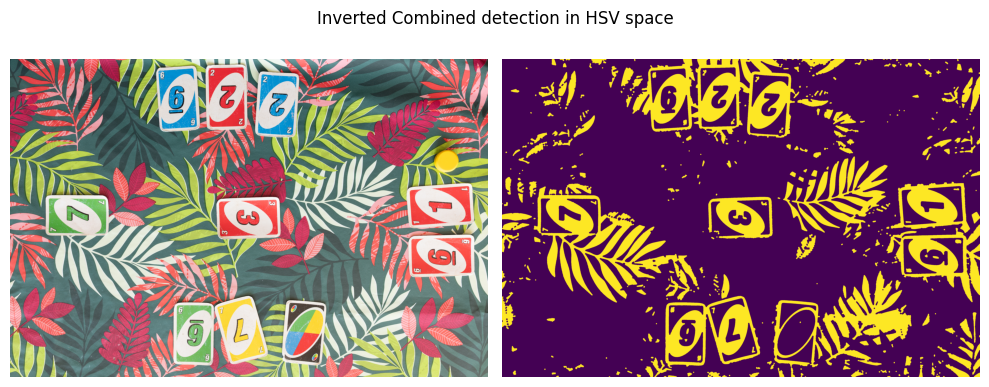

In [187]:
#testing some openings and closings to see if it improves the contour detection
final_mask = combined_mask(img, color_masks)
print(final_mask.shape)


final_mask = apply_closing(final_mask, disk_size=5)
final_mask = apply_opening(final_mask, disk_size=5)

plot_thresholded_image(
            img=img,
            func=lambda img: final_mask,
            title=f"Combined detection in HSV space"
        )

inverted_final_mask = np.invert(final_mask)
plot_thresholded_image(
            img=img,
            func=lambda img: inverted_final_mask,
            title=f"Inverted Combined detection in HSV space"
        )

(36, 2)


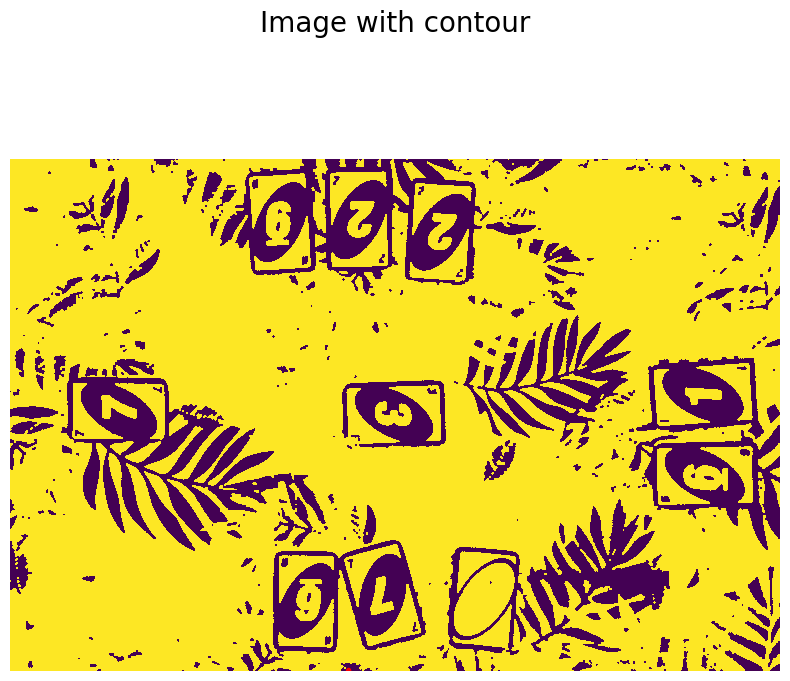

In [188]:

contours = find_contour(np.array([final_mask]))
print(contours[0].shape)
#print(img.shape)
display_img_with_contour(final_mask, "", "Image with contour", cnt=contours[0])


54
Number of large contours: 28


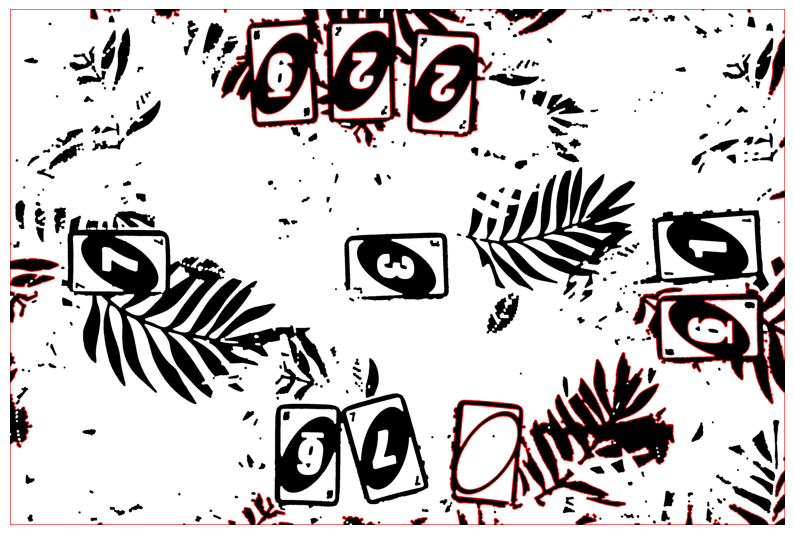

In [189]:
inverted_final_mask = np.invert(inverted_final_mask)
contours2, hierarchy = cv2.findContours(
    inverted_final_mask.astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
contours2 = [cnt[:, 0, :] for cnt in contours2]
print(len(contours2))
#display_img_with_contour(inverted_final_mask, "", "Image with contour - OpenCV", cnt=contours2[0])


large_contours = []

for c in contours2:

    area = cv2.contourArea(c)
    if area > 1000:
        large_contours.append(c)
        
print(f"Number of large contours: {len(large_contours)}")
        
result = inverted_final_mask.copy()
gray_image = (result * 255).astype(np.uint8)
result = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)

cv2.drawContours(
    result,
    large_contours,
    -1,
    (0, 0, 255),
    3
)

plt.figure(figsize=(10,8))

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

plt.axis("off")
plt.show()

In [190]:
def linear_interpolation(contours: np.ndarray, n_samples: int = 11):
    """
    Perform interpolation/resampling of the contour across n_samples.
    
    Args
    ----
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the 
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements 
        that form the contour. 
    n_samples: int
        Number of samples to consider along the contour.

    Return
    ------
    contours_inter: np.ndarray (N, n_samples, 2)
        Interpolated contour with n_samples
    """

    N = len(contours)
    contours_inter = np.zeros((N, n_samples, 2))
    
    # ------------------
    # Your code here ... 
    # ------------------
    for i in range(N):
        contour = contours[i]
        length = len(contour)
        if length >= n_samples:
            indices = np.linspace(0, length - 1, n_samples).astype(int)
            contours_inter[i] = contour[indices]
        else:
            indices = np.arange(length)
            contours_inter[i, :length] = contour[indices]
            contours_inter[i, length:] = contour[-1]
        
    return contours_inter



#this function was 100% vibe coded
def plot_interpolated_contours(
    mask: np.ndarray,
    contours_inter: np.ndarray,
    color: str = "red",
    point_size: int = 10,
    linewidth: int = 2,
):
    """
    Display interpolated contours on top of a mask image.

    Args
    ----
    mask: np.ndarray (H, W)
        Binary/grayscale mask image.

    contours_inter: np.ndarray (N, n_samples, 2)
        Interpolated contours.

    color: str
        Color used for contour visualization.

    point_size: int
        Size of sampled contour points.

    linewidth: int
        Width of contour lines.
    """

    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(10, 10))

    # Show mask
    plt.imshow(mask, cmap="gray")

    # Plot each contour
    for contour in contours_inter:

        # x/y coordinates
        x = contour[:, 0]
        y = contour[:, 1]

        # Draw contour line
        plt.plot(
            x,
            y,
            color=color,
            linewidth=linewidth
        )

        # Draw sampled points
        plt.scatter(
            x,
            y,
            c=color,
            s=point_size
        )

    plt.gca().invert_yaxis()
    plt.axis("off")
    plt.title("Interpolated Contours")
    plt.show()
    

In [191]:
new_contours = [c.reshape(-1, 2) for c in large_contours]
print(new_contours[0].shape)
print(len(new_contours))


new_contours_inter = linear_interpolation(new_contours, n_samples=25) #now a list of all contoues with N points each
print(new_contours_inter.shape)

(104, 2)
28
(28, 25, 2)


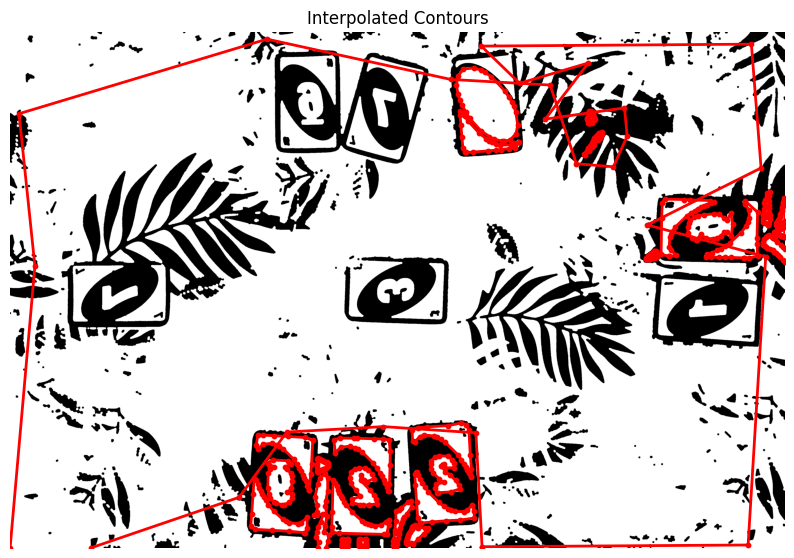

In [192]:

# Plot
plot_interpolated_contours(
    inverted_final_mask,
    new_contours_inter
)